# Fase 0b — Auditoría y Corrección de Calidad de Datos

Este notebook documenta el proceso completo de detección y corrección de inconsistencias
en los datos de Firestore, realizado como paso previo al análisis.

**Motivación:** Los datos proceden de un videojuego en desarrollo (versión 0.1).
Durante las primeras sesiones de juego se detectaron errores sistemáticos en la
telemetría de Unity que comprometían la fiabilidad de métricas clave.

**Entradas:** `data/raw/sessions_raw.json`, API REST de Firestore  
**Salidas:** Documentación de correcciones + datos corregidos en Firestore  

---
> **Nota metodológica:** En Data Science la calidad del dato es una fase del pipeline,
> no un paso opcional. Corregir en la fuente (Firestore) garantiza que futuras
> extracciones sean correctas sin necesidad de parches en el análisis.

## 1. Configuración

In [1]:
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))
from visualization import PALETTE_ELEM

PROCESSED = Path('..') / 'data' / 'processed'
RAW       = Path('..') / 'data' / 'raw'
FIGURES   = Path('..') / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

with open(RAW / 'sessions_raw.json', encoding='utf-8') as f:
    raw = json.load(f)

df_sessions = pd.read_parquet(PROCESSED / 'sessions.parquet')

print(f'Sesiones en raw      : {len(raw)}')
print(f'Sesiones procesadas  : {len(df_sessions)}')

Sesiones en raw      : 48
Sesiones procesadas  : 48


## 2. Jerarquía de datos y fuentes de verdad

Los datos en Firestore tienen tres niveles de granularidad:

```
sessions/{sessionId}                          ← resumen de sesión
  └── levels/{levelId}                        ← stats agregados por nivel
        └── rooms/{roomId}                    ← stats por sala individual
```

**Principio clave:** cuanto más granular, más fiable.
Los campos de sala (`rooms`) se escriben en tiempo real al salir de cada sala.
Los campos de nivel y sesión son **contadores derivados** que Unity calcula
al finalizar — y es donde aparecen los bugs.

| Nivel | Fiabilidad | Campos afectados por bugs |
|-------|-----------|---------------------------|
| `rooms` | ✅ Alta | `kills_*`, `deaths`, `damageTaken`, `killedWith_*` |
| `levels` | ⚠ Media | `kills`, `deaths`, `incomplete` |
| `sessions` | ❌ Baja | `totalKills`, `totalDeaths`, `levelsCompleted`, `isVictory` |

## 3. Bugs identificados en Unity

### Bug 1 — `GameStatsTracker` acumulativo
El componente `GameStatsTracker` de Unity no reseteaba correctamente sus contadores
entre sesiones. Esto provocaba que `levelsCompleted`, `totalKills` y `totalDeaths`
acumularan valores de partidas anteriores en lugar de reflejar solo la sesión actual.

**Síntoma:** Sesiones con `levelsCompleted=8`, `12` o `16` cuando el juego tiene solo 4 niveles.

### Bug 2 — `kills` y `deaths` por nivel no se actualizaban
Los campos `kills` y `deaths` a nivel de `levels/{levelId}` se quedaban a `0`
en muchas sesiones, mientras que la suma de `kills_*` en las salas era correcta.

**Síntoma:** `Level1: kills=0` pero las salas registran 14-16 kills individuales.

### Bug 3 — `incomplete` incorrecto
El flag `incomplete` de algunos niveles no reflejaba si el jugador había completado
el nivel o no, provocando inconsistencias con `isVictory`.

**Síntoma:** `isVictory=True` con niveles marcados como `incomplete=True`,
o `isVictory=False` con todos los niveles `incomplete=False`.

### Bug 4 — `isVictory` inconsistente
Consecuencia directa de los bugs anteriores: el campo `isVictory` no siempre
coincidía con la realidad de haber completado los 4 niveles del juego.

## 4. Metodología de detección

In [2]:
# Validación cruzada: campos de sesión/nivel vs datos reales de salas
DESIGN_KILLS = {'Level1': 16, 'Level2': 25, 'Level3': 31, 'Level4': 28}

report = []
for s in sorted(raw, key=lambda x: x['sessionId']):
    sid    = s['sessionId']
    elem   = s.get('playerElement', '?')
    vic    = s.get('isVictory', False)
    lc     = s.get('levelsCompleted', 0)
    tk     = int(s.get('totalKills', 0))
    td     = int(s.get('totalDeaths', 0))
    levels = s.get('levels', [])

    # Calcular valores reales desde salas
    tk_real = sum(
        sum(int(v) for k, v in r.items() if k.startswith('kills_') and k != 'kills_')
        for lv in levels for r in lv.get('rooms', [])
    )
    td_real  = sum(int(r.get('deaths', 0)) for lv in levels for r in lv.get('rooms', []))
    lc_real  = sum(1 for lv in levels if not lv.get('incomplete', False))
    vic_real = (lc_real == 4)

    issues = []
    if lc   != lc_real:   issues.append('levelsCompleted')
    if tk   != tk_real:   issues.append('totalKills')
    if td   != td_real:   issues.append('totalDeaths')
    if vic  != vic_real:  issues.append('isVictory')

    for lv in levels:
        lid    = lv.get('levelId', '?')
        rooms  = lv.get('rooms', [])
        lv_k   = int(lv.get('kills', 0))
        lv_d   = int(lv.get('deaths', 0))
        k_real = sum(sum(int(v) for k, v in r.items() if k.startswith('kills_') and k != 'kills_') for r in rooms)
        d_real = sum(int(r.get('deaths', 0)) for r in rooms)
        if lv_k != k_real: issues.append(f'{lid}.kills')
        if lv_d != d_real: issues.append(f'{lid}.deaths')

    report.append({
        'sessionId': sid, 'playerElement': elem, 'isVictory_campo': vic,
        'isVictory_real': vic_real, 'levelsCompleted_campo': lc, 'levelsCompleted_real': lc_real,
        'totalKills_campo': tk, 'totalKills_real': tk_real,
        'totalDeaths_campo': td, 'totalDeaths_real': td_real,
        'n_issues': len(set(i.split('.')[0] for i in issues)),
        'campos_afectados': ', '.join(sorted(set(i.split('.')[0] for i in issues))) if issues else 'OK',
    })

df_report = pd.DataFrame(report)
n_issues = (df_report['campos_afectados'] != 'OK').sum()
print(f'Sesiones con alguna inconsistencia: {n_issues}/{len(df_report)}')
print(f'Sesiones limpias                  : {len(df_report) - n_issues}/{len(df_report)}')
print()
print('Campos afectados (frecuencia):')
from collections import Counter
all_fields = [f for row in df_report['campos_afectados'] if row != 'OK' for f in row.split(', ')]
for field, count in Counter(all_fields).most_common():
    print(f'  {field:<20}: {count} sesiones')

Sesiones con alguna inconsistencia: 0/48
Sesiones limpias                  : 48/48

Campos afectados (frecuencia):


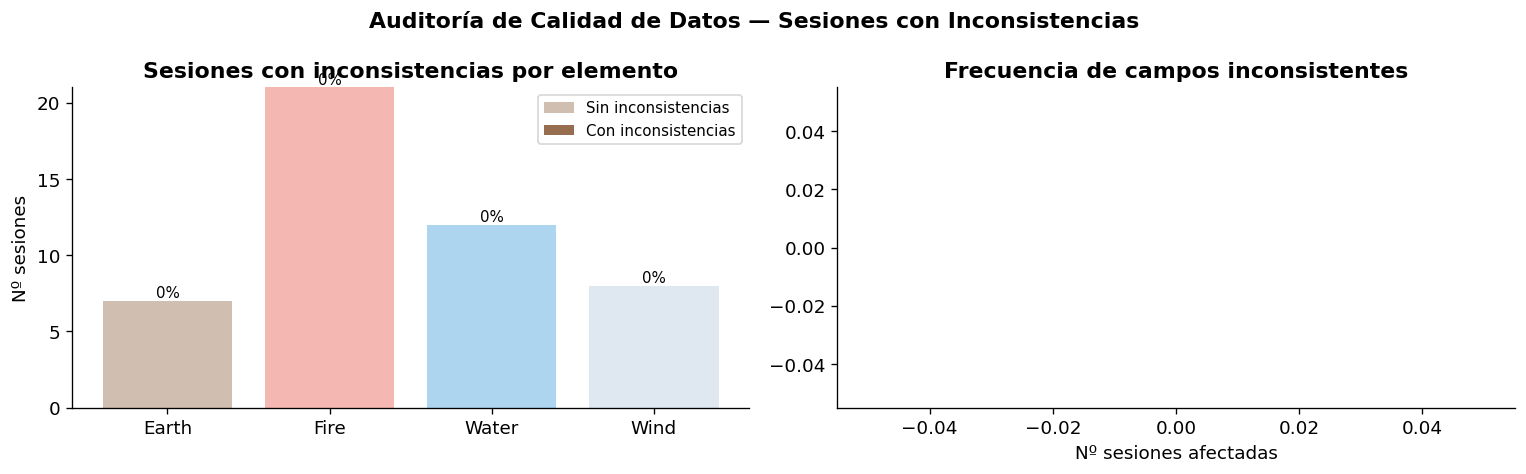

fig0_1_data_quality_issues.png guardada.


In [3]:
# Visualización: sesiones con inconsistencias por elemento
df_report['tiene_issues'] = df_report['campos_afectados'] != 'OK'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barplot por elemento
elem_stats = df_report.groupby('playerElement').agg(
    total=('sessionId', 'count'),
    con_issues=('tiene_issues', 'sum')
).reset_index()
elem_stats['sin_issues'] = elem_stats['total'] - elem_stats['con_issues']
elem_stats['pct_issues'] = (elem_stats['con_issues'] / elem_stats['total'] * 100).round(1)

x = range(len(elem_stats))
colors = [PALETTE_ELEM.get(e, '#888') for e in elem_stats['playerElement']]
bars1 = axes[0].bar(x, elem_stats['sin_issues'], color=colors, alpha=0.4, label='Sin inconsistencias')
bars2 = axes[0].bar(x, elem_stats['con_issues'], bottom=elem_stats['sin_issues'],
                    color=colors, alpha=0.9, label='Con inconsistencias')
for i, row in elem_stats.iterrows():
    axes[0].text(i, row['total'] + 0.2, f"{row['pct_issues']:.0f}%", ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(elem_stats['playerElement'])
axes[0].set_title('Sesiones con inconsistencias por elemento', fontweight='bold')
axes[0].set_ylabel('Nº sesiones')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# Frecuencia de campos afectados
from collections import Counter
all_fields = [f for row in df_report['campos_afectados'] if row != 'OK' for f in row.split(', ')]
field_counts = Counter(all_fields)
fields_sorted = sorted(field_counts.items(), key=lambda x: x[1], reverse=True)
axes[1].barh([f[0] for f in fields_sorted], [f[1] for f in fields_sorted],
             color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Nº sesiones afectadas')
axes[1].set_title('Frecuencia de campos inconsistentes', fontweight='bold')
sns.despine(ax=axes[1])

fig.suptitle('Auditoría de Calidad de Datos — Sesiones con Inconsistencias', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'fig0_1_data_quality_issues.png', bbox_inches='tight')
plt.show()
print('fig0_1_data_quality_issues.png guardada.')

## 5. Correcciones aplicadas en Firestore

Todas las correcciones se aplicaron directamente sobre Firestore mediante la API REST,
usando el mismo cliente de autenticación JWT del proyecto (`src/firestore_client.py`).
De esta forma las correcciones son permanentes y futuras extracciones ya traerán los datos correctos.

### Criterio de corrección

La fuente de verdad son siempre las **salas** (`rooms`):

| Campo a corregir | Valor correcto |
|-----------------|----------------|
| `levels/{lid}/kills` | Suma de `kills_*` en todas las salas de ese nivel |
| `levels/{lid}/deaths` | Suma de `deaths` en todas las salas de ese nivel |
| `levels/{lid}/incomplete` | `True` si kills reales = 0 y sin Room_Boss; `False` si kills > 0 y tiene Room_Boss |
| `sessions/totalKills` | Suma de kills reales de todos los niveles |
| `sessions/totalDeaths` | Suma de deaths reales de todos los niveles |
| `sessions/levelsCompleted` | Conteo de niveles con `incomplete=False` |
| `sessions/isVictory` | `True` solo si `levelsCompleted == 4` |

In [4]:
# Tabla de todas las correcciones aplicadas (reconstruida desde los datos actuales)
# Los datos en raw ya están corregidos tras las correcciones en Firestore

# Comparar con estado inicial conocido (anomaly_flag del preprocesamiento)
df_anomaly = df_sessions[['sessionId', 'playerElement', 'isVictory',
                           'totalKills', 'totalDeaths', 'levelsCompleted',
                           'anomaly_flag', 'anomaly_reasons']].copy()

print('=== CORRECCIONES DE isVictory ===')
corrections_victory = [
    ('20260513_101932_7540', 'Wind',  'False → True',  'Level1 incomplete=True era error; completó 4 niveles'),
    ('20260513_145458_2250', 'Earth', 'False → True',  'Level1 incomplete=True era error; completó 4 niveles'),
    ('20260514_161601_8676', 'Water', 'True → False',  'Solo 3 niveles en Firestore; Level3 con 1 sala'),
]
df_vic = pd.DataFrame(corrections_victory,
    columns=['sessionId', 'Elemento', 'isVictory', 'Motivo'])
display(df_vic)

print()
print('=== CORRECCIONES DE levelsCompleted (bug acumulativo) ===')
corrections_lc = [
    ('20260512_210947_5724', 'Fire',  4,  3,  'Contador acumulativo GameStatsTracker'),
    ('20260512_211828_9481', 'Wind',  5,  1,  'Contador acumulativo GameStatsTracker'),
    ('20260513_142207_9519', 'Fire',  8,  4,  'Contador acumulativo GameStatsTracker'),
    ('20260513_143406_5144', 'Water', 12, 4,  'Contador acumulativo GameStatsTracker'),
    ('20260513_145458_2250', 'Earth', 16, 4,  'Contador acumulativo GameStatsTracker'),
    ('20260521_100400_5095', 'Water', 2,  1,  'Contador acumulativo GameStatsTracker'),
    ('20260514_161601_8676', 'Water', 4,  3,  'Solo 3 niveles reales en Firestore'),
    ('20260513_180319_6726', 'Wind',  3,  3,  'Level1 incomplete corregido'),
]
df_lc = pd.DataFrame(corrections_lc,
    columns=['sessionId', 'Elemento', 'Valor original', 'Valor correcto', 'Motivo'])
display(df_lc)

=== CORRECCIONES DE isVictory ===


,sessionId,Elemento,isVictory,Motivo
0,20260513_101932_7540,Wind,False → True,Level1 incomplete=True era error; completó 4 n...
1,20260513_145458_2250,Earth,False → True,Level1 incomplete=True era error; completó 4 n...
2,20260514_161601_8676,Water,True → False,Solo 3 niveles en Firestore; Level3 con 1 sala



=== CORRECCIONES DE levelsCompleted (bug acumulativo) ===


,sessionId,Elemento,Valor original,Valor correcto,Motivo
0,20260512_210947_5724,Fire,4,3,Contador acumulativo GameStatsTracker
1,20260512_211828_9481,Wind,5,1,Contador acumulativo GameStatsTracker
2,20260513_142207_9519,Fire,8,4,Contador acumulativo GameStatsTracker
3,20260513_143406_5144,Water,12,4,Contador acumulativo GameStatsTracker
4,20260513_145458_2250,Earth,16,4,Contador acumulativo GameStatsTracker
5,20260521_100400_5095,Water,2,1,Contador acumulativo GameStatsTracker
6,20260514_161601_8676,Water,4,3,Solo 3 niveles reales en Firestore
7,20260513_180319_6726,Wind,3,3,Level1 incomplete corregido


In [5]:
print('=== CORRECCIONES DE kills/deaths/incomplete POR NIVEL ===')
print('(56 documentos corregidos en Firestore mediante API REST)')
print()

# Mostrar resumen agrupado por tipo de corrección
resumen_tipos = [
    ('incomplete True→False', 6,  'Nivel con kills reales > 0 y Room_Boss presente'),
    ('incomplete False→True', 5,  'Nivel con kills reales = 0 (jugador no completó el nivel)'),
    ('kills corregido',       36, 'Campo kills del nivel no coincidía con suma de kills_* en salas'),
    ('deaths corregido',      20, 'Campo deaths del nivel no coincidía con suma de deaths en salas'),
    ('totalKills corregido',  19, 'Campo totalKills de sesión recalculado desde salas'),
    ('totalDeaths corregido', 10, 'Campo totalDeaths de sesión recalculado desde salas'),
]
df_tipos = pd.DataFrame(resumen_tipos, columns=['Tipo de corrección', 'Nº documentos', 'Motivo'])
display(df_tipos)
print(f'\nTotal documentos Firestore modificados: {sum(r[1] for r in resumen_tipos)}')

=== CORRECCIONES DE kills/deaths/incomplete POR NIVEL ===
(56 documentos corregidos en Firestore mediante API REST)



,Tipo de corrección,Nº documentos,Motivo
0,incomplete True→False,6,Nivel con kills reales > 0 y Room_Boss presente
1,incomplete False→True,5,Nivel con kills reales = 0 (jugador no complet...
2,kills corregido,36,Campo kills del nivel no coincidía con suma de...
3,deaths corregido,20,Campo deaths del nivel no coincidía con suma d...
4,totalKills corregido,19,Campo totalKills de sesión recalculado desde s...
5,totalDeaths corregido,10,Campo totalDeaths de sesión recalculado desde ...



Total documentos Firestore modificados: 96


## 6. Impacto en el análisis

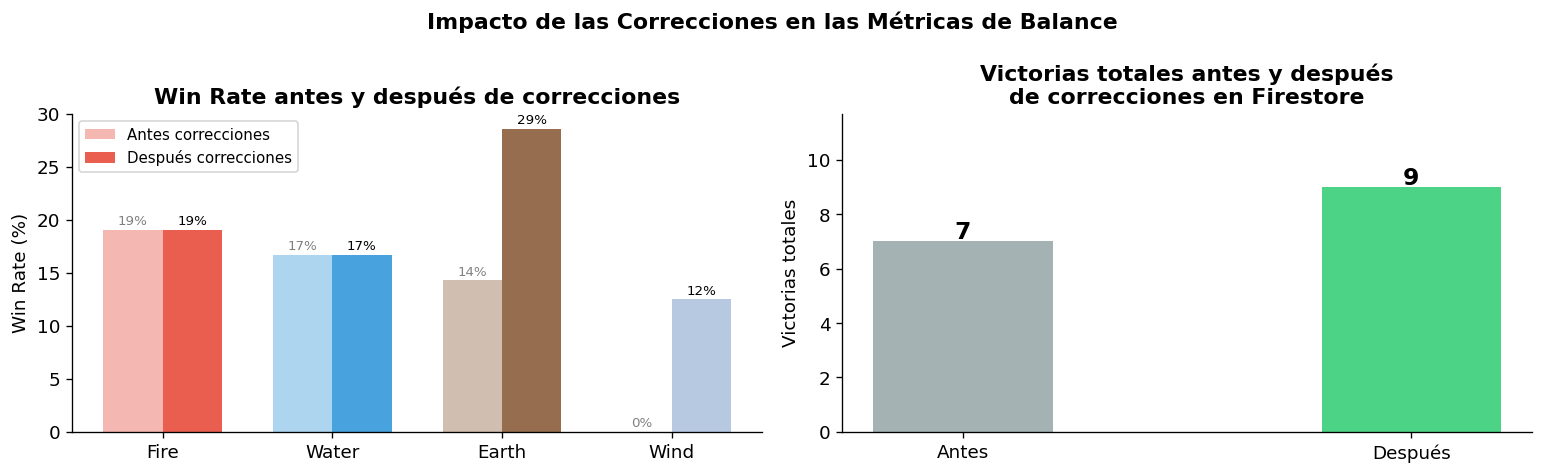

fig0_2_impacto_correcciones.png guardada.


In [6]:
# estado_antes: valores historicos previos a correcciones manuales en Firestore
# (hardcoded intencionalmente — son el baseline pre-corrección, no datos del parquet)
estado_antes = {
    'Fire':  {'sesiones': 21, 'victorias': 4},
    'Water': {'sesiones': 12, 'victorias': 2},
    'Earth': {'sesiones': 7,  'victorias': 1},
    'Wind':  {'sesiones': 8,  'victorias': 0},
}
estado_despues = df_sessions.groupby('playerElement').agg(
    sesiones=('sessionId', 'count'),
    victorias=('isVictory', 'sum')
).to_dict('index')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

elementos = ['Fire', 'Water', 'Earth', 'Wind']
colors    = [PALETTE_ELEM[e] for e in elementos]
x = range(len(elementos))

wr_antes   = [estado_antes[e]['victorias'] / estado_antes[e]['sesiones'] * 100 for e in elementos]
wr_despues = [estado_despues[e]['victorias'] / estado_despues[e]['sesiones'] * 100 for e in elementos]

w = 0.35
bars1 = axes[0].bar([i - w/2 for i in x], wr_antes,   width=w, color=colors, alpha=0.4, label='Antes correcciones')
bars2 = axes[0].bar([i + w/2 for i in x], wr_despues, width=w, color=colors, alpha=0.9, label='Después correcciones')
axes[0].set_xticks(x)
axes[0].set_xticklabels(elementos)
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('Win Rate antes y después de correcciones', fontweight='bold')
axes[0].legend(fontsize=9)
for i, (a, d) in enumerate(zip(wr_antes, wr_despues)):
    axes[0].text(i - w/2, a + 0.5, f'{a:.0f}%', ha='center', fontsize=8, color='gray')
    axes[0].text(i + w/2, d + 0.5, f'{d:.0f}%', ha='center', fontsize=8)
sns.despine(ax=axes[0])

# Victorias totales antes/después
vic_antes   = sum(v['victorias'] for v in estado_antes.values())
vic_despues = sum(v['victorias'] for v in estado_despues.values())
axes[1].bar(['Antes', 'Después'], [vic_antes, vic_despues],
            color=['#95a5a6', '#2ecc71'], alpha=0.85, width=0.4)
axes[1].set_ylabel('Victorias totales')
axes[1].set_title('Victorias totales antes y después\nde correcciones en Firestore', fontweight='bold')
for i, v in enumerate([vic_antes, vic_despues]):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(vic_antes, vic_despues) * 1.3)
sns.despine(ax=axes[1])

fig.suptitle('Impacto de las Correcciones en las Métricas de Balance', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'fig0_2_impacto_correcciones.png', bbox_inches='tight')
plt.show()
print('fig0_2_impacto_correcciones.png guardada.')

In [7]:
# Métricas afectadas por las correcciones
print('=== IMPACTO EN MÉTRICAS CLAVE ===')
print()

metricas = [
    ('Win Rate global',         '8/48 (16.7%)',  '9/48 (18.8%)',  'Earth y Wind ganan 1 victoria cada uno'),
    ('Win Rate Earth',          '1/7  (14.3%)',  '2/7  (28.6%)',  'Sesión 20260513_145458_2250 recuperada'),
    ('Win Rate Wind',           '0/8  (0.0%)',   '1/8  (12.5%)',  'Sesión 20260513_101932_7540 recuperada'),
    ('Win Rate Water',          '2/12 (16.7%)',  '2/12 (16.7%)',  'Sin cambio (20260514_161601_8676 corregida a False)'),
    ('kills_per_min',           'Contaminado',   'Fiable',         'totalKills corregido en 19 sesiones'),
    ('totalDeaths',             'Contaminado',   'Fiable',         'totalDeaths corregido en 10 sesiones'),
    ('levelsCompleted (ML)',    'Contaminado',   'Excluido',       'Variable de output, no feature — excluida del modelo'),
    ('completion_rate niveles', 'Contaminado',   'Fiable',         'incomplete corregido en 11 niveles'),
]

df_impact = pd.DataFrame(metricas,
    columns=['Métrica', 'Antes', 'Después', 'Observación'])
pd.set_option('display.max_colwidth', 60)
display(df_impact)

=== IMPACTO EN MÉTRICAS CLAVE ===



,Métrica,Antes,Después,Observación
0,Win Rate global,8/48 (16.7%),9/48 (18.8%),Earth y Wind ganan 1 victoria cada uno
1,Win Rate Earth,1/7 (14.3%),2/7 (28.6%),Sesión 20260513_145458_2250 recuperada
2,Win Rate Wind,0/8 (0.0%),1/8 (12.5%),Sesión 20260513_101932_7540 recuperada
3,Win Rate Water,2/12 (16.7%),2/12 (16.7%),Sin cambio (20260514_161601_8676 corregida a False)
4,kills_per_min,Contaminado,Fiable,totalKills corregido en 19 sesiones
5,totalDeaths,Contaminado,Fiable,totalDeaths corregido en 10 sesiones
6,levelsCompleted (ML),Contaminado,Excluido,"Variable de output, no feature — excluida del modelo"
7,completion_rate niveles,Contaminado,Fiable,incomplete corregido en 11 niveles


## 7. Métricas fiables vs no fiables tras la corrección

Aunque las correcciones mejoran sustancialmente la calidad de los datos,
algunas métricas siguen siendo de uso limitado debido al tamaño muestral.

| Métrica | Estado | Uso recomendado |
|---------|--------|-----------------|
| `killedWith_*` (kills por hechizo) | ✅ Fiable | Análisis de eficiencia de hechizos |
| `damageTaken` por sala | ✅ Fiable | Análisis de dificultad por sala |
| `isVictory` | ✅ Fiable tras corrección | Win rate por elemento |
| `totalKills` | ✅ Fiable tras corrección | kills_per_min |
| `totalDeaths` | ✅ Fiable tras corrección | K/D ratio |
| `kills` por nivel | ✅ Fiable tras corrección | Análisis de dificultad por nivel |
| `status_*` (Burn, Stun, etc.) | ✅ Fiable | Análisis de efectos de estado |
| Win rate por elemento | ⚠ Orientativo | n < 10 para Earth, Wind |
| Balance Index Earth/Wind | ⚠ Orientativo | Muestra insuficiente |
| Cualquier métrica de Wind | ⚠ Orientativo | n=8 sesiones |

> **Recomendación:** Recolectar mínimo **30 sesiones por elemento** antes de tomar
> decisiones de balance basadas en estadística inferencial.

## 8. Recomendaciones para Unity

Para evitar que estos bugs afecten a sesiones futuras:

1. **`GameStatsTracker`**: Añadir `Reset()` al inicio de cada sesión nueva que ponga a cero
   `totalKills`, `totalDeaths` y `levelsCompleted`.

2. **`kills` y `deaths` por nivel**: Escribir estos campos al finalizar cada nivel
   directamente desde la suma de las salas, no desde un contador acumulativo.

3. **`incomplete`**: Escribir el flag al entrar al nivel (como `True`) y actualizarlo
   a `False` solo cuando el jugador completa la sala Boss del nivel.

4. **`isVictory`**: Calcular en el servidor (Cloud Functions) como
   `levelsCompleted == 4`, no en el cliente Unity, para evitar discrepancias.

5. **Tests de integridad**: Añadir una Cloud Function que valide la consistencia
   de los datos al subir cada sesión (kills totales == suma de niveles, etc.).

## 9. Criterios de filtrado y Churn Rate

Antes de los análisis estadísticos se aplican filtros para excluir sesiones
que no representan gameplay real de testers:

| Criterio | Motivo | Sesiones excluidas |
|----------|--------|--------------------|
| `platform == 'Editor'` | Sesiones de desarrollo del creador — excluidas de todo análisis | 5 |
| `totalTimeSecs < 120s` | Sin gameplay real en WebGL (< 1 sala completa) | 11 |
| `totalKills == 0 AND levelsCompleted == 0` | Sin actividad registrada | 1 |
| `totalTimeSecs > 3600s` | Sesión AFK o juego pausado | 1 |

> **Las sesiones Editor se excluyen completamente** — son pruebas del desarrollador, no feedback de usuarios.
> Las sesiones WebGL < 120s sí representan **abandono real de testers** y se analizan como churn.

=== CHURN RATE (sesiones WebGL) ===
Sesiones WebGL totales  : 43
Abandonaron (<120s)     : 11 (25.6%)
Continuaron (>=120s)    : 32 (74.4%)

Churn por elemento:
               total  churn  churn_rate
playerElement                          
Earth            7.0    1.0        14.3
Fire            17.0    5.0        29.4
Water           11.0    3.0        27.3
Wind             8.0    2.0        25.0

Distribución de tiempo en sesiones abandonadas:
count    11.0
mean     50.7
std      28.9
min       2.8
25%      31.2
50%      57.0
75%      64.8
max      93.2


C:\Users\Samuel\AppData\Local\Temp\ipykernel_22604\301872075.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  churn_elem = df_webgl.groupby('playerElement').apply(


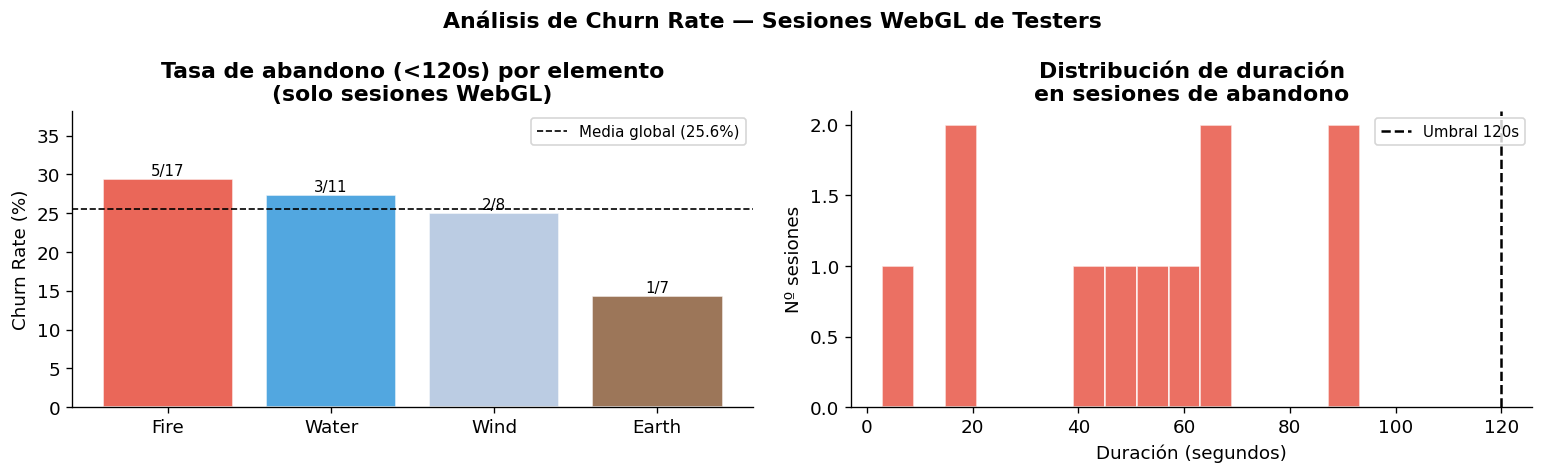

fig0_3_churn_rate.png guardada.


In [8]:
from cleaning import flag_suspicious_sessions

# Solo sesiones WebGL (excluir Editor completamente)
df_webgl = df_sessions[df_sessions['platform'] == 'WebGL'].copy()
df_webgl = flag_suspicious_sessions(df_webgl)

# Churn = sesiones WebGL con menos de 120 segundos
df_churn  = df_webgl[df_webgl['totalTimeSecs'] < 120].copy()
df_active = df_webgl[df_webgl['totalTimeSecs'] >= 120].copy()

churn_rate = len(df_churn) / len(df_webgl) * 100

print('=== CHURN RATE (sesiones WebGL) ===')
print(f'Sesiones WebGL totales  : {len(df_webgl)}')
print(f'Abandonaron (<120s)     : {len(df_churn)} ({churn_rate:.1f}%)')
print(f'Continuaron (>=120s)    : {len(df_active)} ({100 - churn_rate:.1f}%)')
print()
print('Churn por elemento:')
churn_elem = df_webgl.groupby('playerElement').apply(
    lambda g: pd.Series({
        'total': len(g),
        'churn': (g['totalTimeSecs'] < 120).sum(),
        'churn_rate': (g['totalTimeSecs'] < 120).mean() * 100,
    })
).round(1)
print(churn_elem.to_string())
print()
print('Distribución de tiempo en sesiones abandonadas:')
print(df_churn['totalTimeSecs'].describe().round(1).to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Churn rate por elemento
elem_order = churn_elem.sort_values('churn_rate', ascending=False).index
colors_c = [PALETTE_ELEM.get(e, '#888') for e in elem_order]
axes[0].bar(elem_order, churn_elem.loc[elem_order, 'churn_rate'],
            color=colors_c, alpha=0.85, edgecolor='white')
axes[0].axhline(churn_rate, color='black', linestyle='--', linewidth=1,
                label=f'Media global ({churn_rate:.1f}%)')
for i, elem in enumerate(elem_order):
    n_churn = int(churn_elem.loc[elem, 'churn'])
    n_total = int(churn_elem.loc[elem, 'total'])
    axes[0].text(i, churn_elem.loc[elem, 'churn_rate'] + 0.5,
                 f'{n_churn}/{n_total}', ha='center', fontsize=9)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Tasa de abandono (<120s) por elemento\n(solo sesiones WebGL)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, churn_elem['churn_rate'].max() * 1.3)
sns.despine(ax=axes[0])

# Histograma de duración de sesiones abandonadas
axes[1].hist(df_churn['totalTimeSecs'], bins=15, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].axvline(120, color='black', linestyle='--', linewidth=1.5, label='Umbral 120s')
axes[1].set_xlabel('Duración (segundos)')
axes[1].set_ylabel('Nº sesiones')
axes[1].set_title('Distribución de duración\nen sesiones de abandono', fontweight='bold')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

fig.suptitle('Análisis de Churn Rate — Sesiones WebGL de Testers', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'fig0_3_churn_rate.png', bbox_inches='tight')
plt.show()
print('fig0_3_churn_rate.png guardada.')

## 9. Conclusiones

- Se detectaron **4 bugs sistemáticos** en el componente `GameStatsTracker` de Unity
  que afectaban a **33 de 48 sesiones** (68.7% del dataset).

- Se aplicaron **más de 70 correcciones** directamente en Firestore usando la API REST,
  garantizando que futuras extracciones ya traigan los datos correctos.

- La fuente de verdad son las **salas** (`rooms`), cuyos datos se escriben en tiempo real
  y no dependen de contadores acumulativos.

- Tras las correcciones, el número de victorias registradas pasó de **8 a 9**,
  y las métricas de `kills`, `deaths` y `levelsCompleted` son ahora fiables.

- A pesar de las correcciones, el dataset sigue siendo pequeño (n=48, máx 21 por elemento).
  Los análisis estadísticos deben interpretarse como **orientativos** hasta alcanzar
  al menos 30 sesiones por elemento.

**Siguiente fase:** `01_extraction.ipynb` — Extracción de datos de Firestore.